# Bitcoin Market Sentiment vs Trader Performance Analysis
### Hyperliquid Trader Data × Fear & Greed Index | 2024–2025

---

**Objective:** Explore the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance on Hyperliquid. Uncover hidden patterns and deliver insights that can drive smarter trading strategies.

**Datasets:**
- `fear_greed_index.csv` — Daily Bitcoin Fear & Greed Index (classification + numeric value)
- `historical_data.csv` — 211K+ trades from 32 Hyperliquid wallets across 246 tokens

**Approach:** Data cleaning → EDA → Sentiment-performance merge → Pattern analysis → Strategy insights

## 1. Setup & Imports

In [1]:
!pip install pandas numpy matplotlib seaborn plotly -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

SENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
SENT_COLORS = ['#D85A30', '#F0997B', '#888780', '#97C459', '#3B6D11']

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load & Preview Data

In [3]:
fg = pd.read_csv('fear_greed_index.csv')
hist = pd.read_csv('historical_data.csv')

print(f'Fear & Greed Index: {fg.shape[0]:,} rows, {fg.shape[1]} columns')
print(f'Historical Trades : {hist.shape[0]:,} rows, {hist.shape[1]} columns')

Fear & Greed Index: 2,644 rows, 4 columns
Historical Trades : 211,224 rows, 16 columns


In [4]:
fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
hist.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 3. Data Cleaning & Preprocessing

In [6]:
# --- Fear & Greed Index ---
fg['date'] = pd.to_datetime(fg['date'])
fg['date_only'] = fg['date'].dt.date
fg['classification'] = fg['classification'].str.strip()

print('Sentiment distribution:')
print(fg['classification'].value_counts())
print(f'\nDate range: {fg["date"].min().date()} → {fg["date"].max().date()}')
print(f'Missing values: {fg.isnull().sum().sum()}')

Sentiment distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

Date range: 2018-02-01 → 2025-05-02
Missing values: 0


In [7]:
# --- Historical Trades ---
hist['trade_date'] = pd.to_datetime(hist['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
hist['date_only']  = hist['trade_date'].dt.date
hist['hour']       = hist['trade_date'].dt.hour
hist['month']      = hist['trade_date'].dt.to_period('M')
hist['weekday']    = hist['trade_date'].dt.day_name()

# Remove rows where date parsing failed
bad_dates = hist['trade_date'].isnull().sum()
hist = hist.dropna(subset=['trade_date'])

print(f'Rows after cleaning: {len(hist):,}  (removed {bad_dates} unparseable dates)')
print(f'Date range: {hist["trade_date"].min().date()} → {hist["trade_date"].max().date()}')
print(f'Unique accounts : {hist["Account"].nunique()}')
print(f'Unique coins    : {hist["Coin"].nunique()}')
print(f'\nMissing values per column:')
print(hist.isnull().sum()[hist.isnull().sum() > 0])

Rows after cleaning: 211,224  (removed 0 unparseable dates)
Date range: 2023-05-01 → 2025-05-01
Unique accounts : 32
Unique coins    : 246

Missing values per column:
Series([], dtype: int64)


In [8]:
# --- Merge datasets on date ---
merged = hist.merge(fg[['date_only', 'classification', 'value']], on='date_only', how='left')

unmatched = merged['classification'].isnull().sum()
print(f'Merged shape : {merged.shape}')
print(f'Trades with no matching sentiment date: {unmatched} ({unmatched/len(merged)*100:.2f}%)')

# Drop the tiny unmatched slice
merged = merged.dropna(subset=['classification'])
print(f'Final working dataset: {len(merged):,} rows')

Merged shape : (211224, 23)
Trades with no matching sentiment date: 6 (0.00%)
Final working dataset: 211,218 rows


## 4. Exploratory Data Analysis (EDA)

In [9]:
# --- Summary statistics ---
print('=== Closed PnL Statistics ===')
print(merged['Closed PnL'].describe().round(2))
print(f'\nTotal realised PnL : ${merged["Closed PnL"].sum():,.0f}')
print(f'Trades with PnL!=0 : {(merged["Closed PnL"]!=0).sum():,}')
print(f'Total volume (USD) : ${merged["Size USD"].sum()/1e6:.1f}M')

=== Closed PnL Statistics ===
count    211218.00
mean         48.55
std         917.99
min     -117990.10
25%           0.00
50%           0.00
75%           5.79
max      135329.09
Name: Closed PnL, dtype: float64

Total realised PnL : $10,254,487
Trades with PnL!=0 : 104,402
Total volume (USD) : $1191.1M


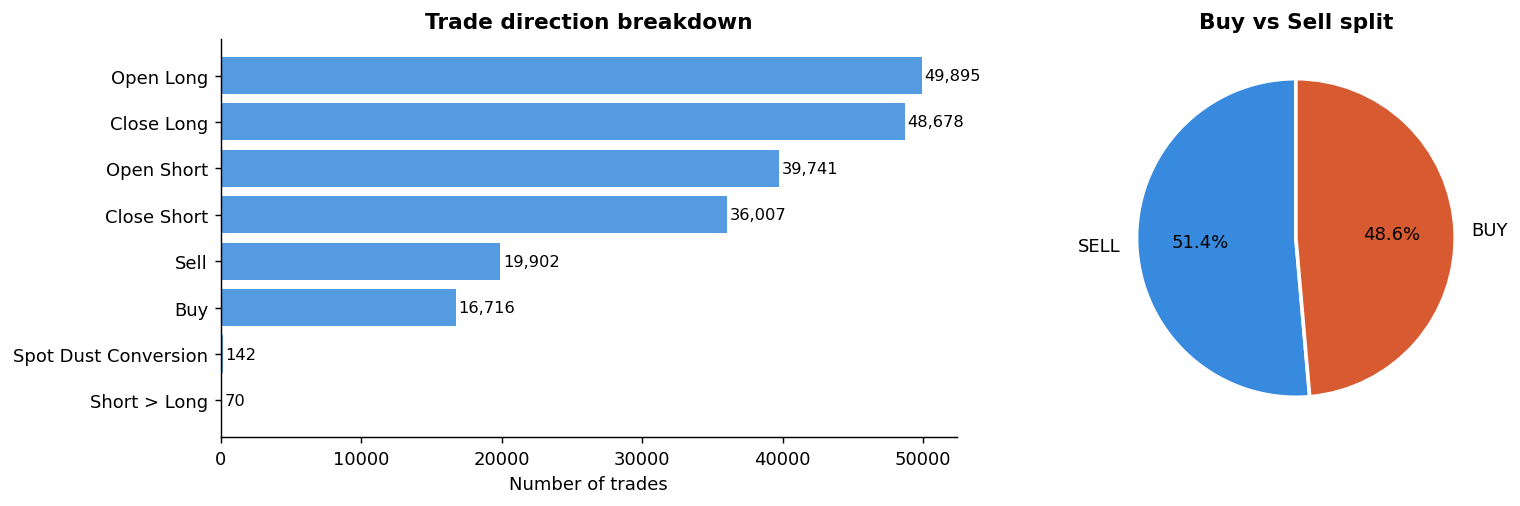

The pool is nearly 50/50 buy vs sell — typical for perp traders who hedge both sides.


In [10]:
# --- Trade direction breakdown ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Direction counts
dir_counts = merged['Direction'].value_counts().head(8)
axes[0].barh(dir_counts.index[::-1], dir_counts.values[::-1], color='#378ADD', alpha=0.85)
axes[0].set_xlabel('Number of trades')
axes[0].set_title('Trade direction breakdown', fontweight='bold')
for i, v in enumerate(dir_counts.values[::-1]):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontsize=9)

# Side (BUY vs SELL)
side_counts = merged['Side'].value_counts()
axes[1].pie(side_counts, labels=side_counts.index, autopct='%1.1f%%',
            colors=['#378ADD', '#D85A30'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Buy vs Sell split', fontweight='bold')

plt.tight_layout()
plt.show()
print('The pool is nearly 50/50 buy vs sell — typical for perp traders who hedge both sides.')

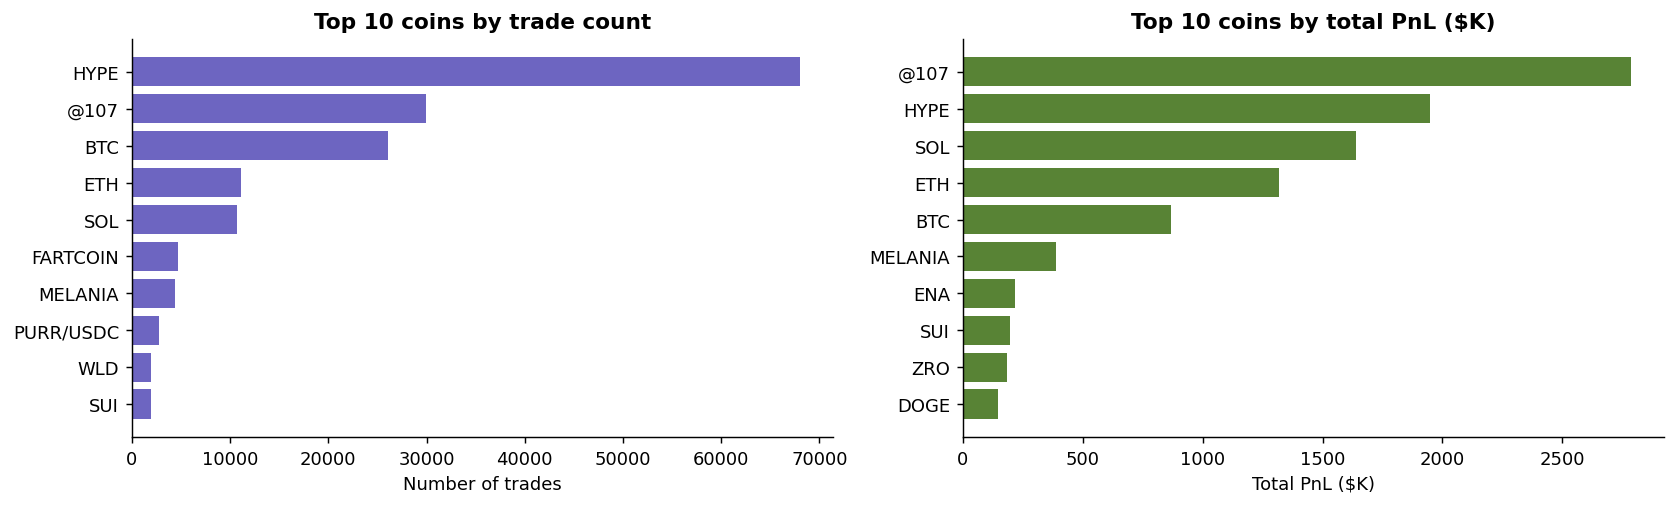

HYPE dominates by trade count (32%) but @107 generated the most dollar PnL ($2.78M).


In [11]:
# --- Top 10 coins by trade count and PnL ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

top_vol = merged['Coin'].value_counts().head(10)
top_pnl = merged.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False).head(10)

axes[0].barh(top_vol.index[::-1], top_vol.values[::-1], color='#534AB7', alpha=0.85)
axes[0].set_title('Top 10 coins by trade count', fontweight='bold')
axes[0].set_xlabel('Number of trades')

axes[1].barh(top_pnl.index[::-1], top_pnl.values[::-1]/1000, color='#3B6D11', alpha=0.85)
axes[1].set_title('Top 10 coins by total PnL ($K)', fontweight='bold')
axes[1].set_xlabel('Total PnL ($K)')

plt.tight_layout()
plt.show()
print('HYPE dominates by trade count (32%) but @107 generated the most dollar PnL ($2.78M).')

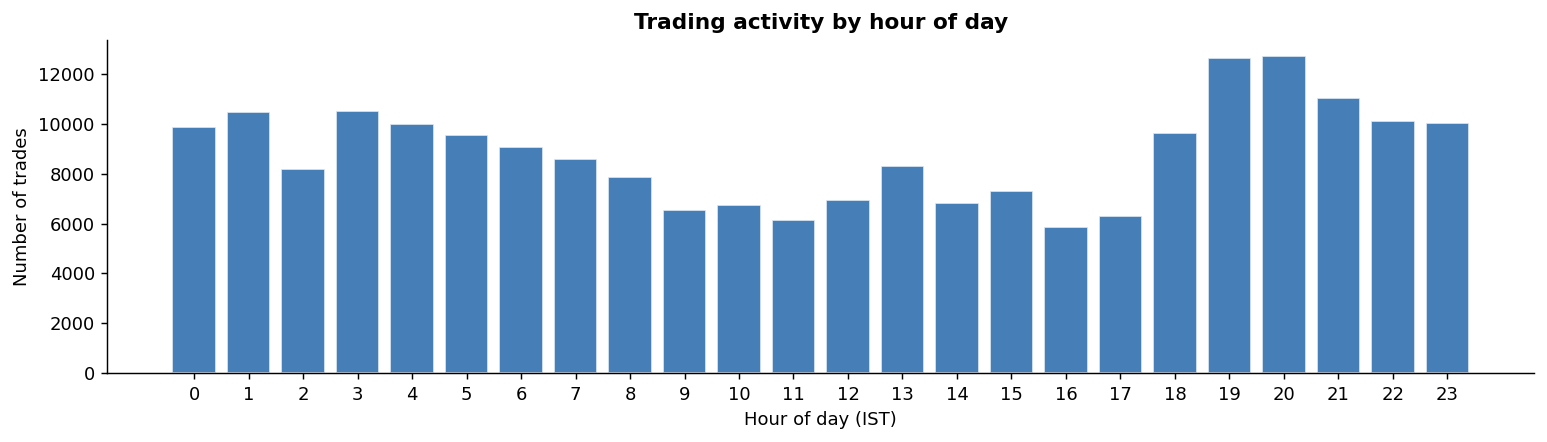

Activity peaks 19:00–21:00 IST (13:30–15:30 UTC) — US market overlap hours.


In [12]:
# --- Hourly trading activity ---
hourly = merged.groupby('hour').size().reset_index(name='count')

plt.figure(figsize=(12, 3.5))
plt.bar(hourly['hour'], hourly['count'], color='#185FA5', alpha=0.8, edgecolor='white')
plt.xticks(range(0, 24))
plt.xlabel('Hour of day (IST)')
plt.ylabel('Number of trades')
plt.title('Trading activity by hour of day', fontweight='bold')
plt.tight_layout()
plt.show()
print('Activity peaks 19:00–21:00 IST (13:30–15:30 UTC) — US market overlap hours.')

## 5. Sentiment Analysis

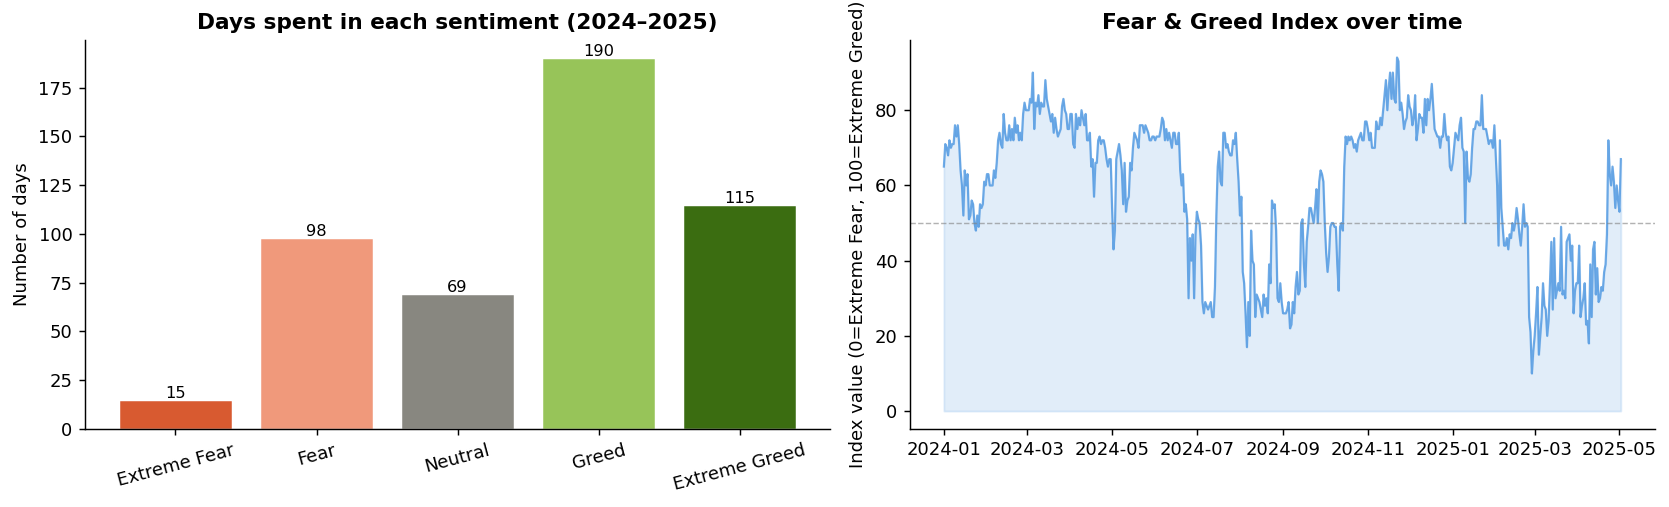

In [13]:
# --- Sentiment distribution in the trading period ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Days per classification
day_sent = fg[fg['date'].dt.year.isin([2024, 2025])]['classification'].value_counts().reindex(SENT_ORDER)
axes[0].bar(SENT_ORDER, day_sent, color=SENT_COLORS, edgecolor='white', linewidth=0.8)
axes[0].set_title('Days spent in each sentiment (2024–2025)', fontweight='bold')
axes[0].set_ylabel('Number of days')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(day_sent):
    axes[0].text(i, v+1, str(v), ha='center', fontsize=9)

# Fear/Greed index over time
fg_period = fg[fg['date'].dt.year.isin([2024, 2025])].copy()
axes[1].plot(fg_period['date'], fg_period['value'], linewidth=1.2, color='#378ADD', alpha=0.7)
axes[1].fill_between(fg_period['date'], fg_period['value'], alpha=0.15, color='#378ADD')
axes[1].axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
axes[1].set_title('Fear & Greed Index over time', fontweight='bold')
axes[1].set_ylabel('Index value (0=Extreme Fear, 100=Extreme Greed)')

plt.tight_layout()
plt.show()

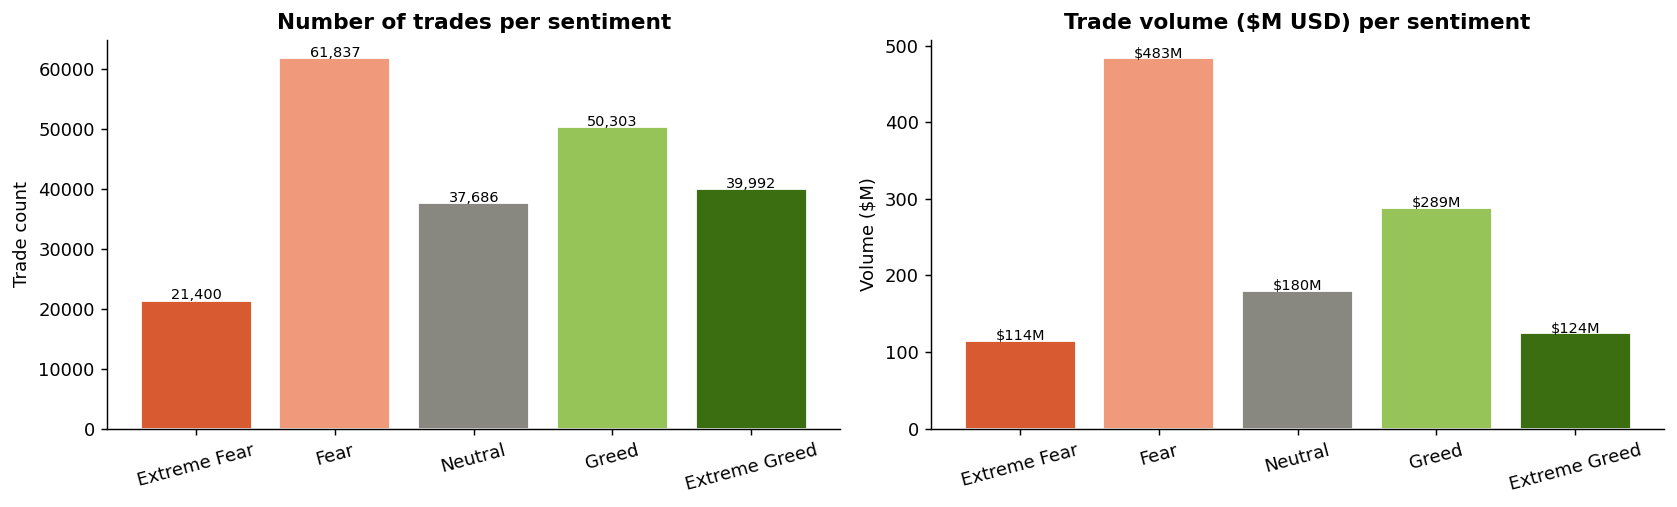

Fear periods attracted the most trading volume ($483M) — traders are most active when markets are fearful.


In [14]:
# --- Trades distribution across sentiments ---
trade_sent = merged.groupby('classification').size().reindex(SENT_ORDER)
vol_sent   = merged.groupby('classification')['Size USD'].sum().reindex(SENT_ORDER) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars1 = axes[0].bar(SENT_ORDER, trade_sent, color=SENT_COLORS, edgecolor='white')
axes[0].set_title('Number of trades per sentiment', fontweight='bold')
axes[0].set_ylabel('Trade count')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, trade_sent):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f'{val:,}', ha='center', fontsize=8)

bars2 = axes[1].bar(SENT_ORDER, vol_sent, color=SENT_COLORS, edgecolor='white')
axes[1].set_title('Trade volume ($M USD) per sentiment', fontweight='bold')
axes[1].set_ylabel('Volume ($M)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, vol_sent):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'${val:.0f}M', ha='center', fontsize=8)

plt.tight_layout()
plt.show()
print('Fear periods attracted the most trading volume ($483M) — traders are most active when markets are fearful.')

## 6. Sentiment vs Trader Performance

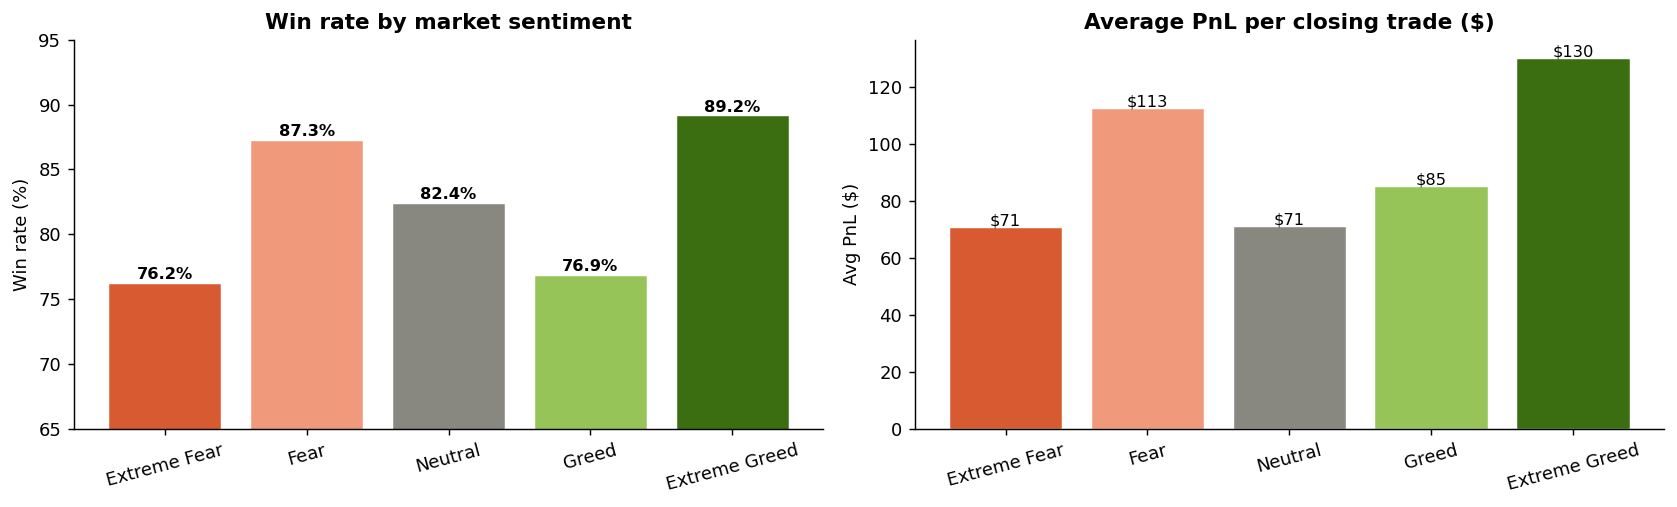


Full win rate table:
                Win Rate %  Trades  Avg PnL ($)  Total PnL ($)
classification                                                
Extreme Fear         76.22   10406    71.027316   7.391102e+05
Fear                 87.29   29808   112.625988   3.357155e+06
Neutral              82.39   18159    71.199993   1.292921e+06
Greed                76.89   25176    85.403927   2.150129e+06
Extreme Greed        89.17   20853   130.205309   2.715171e+06


In [15]:
# --- Win rate by sentiment ---
closing = merged[merged['Closed PnL'] != 0].copy()
closing['win'] = closing['Closed PnL'] > 0

wr = closing.groupby('classification').agg(
    win_rate  = ('win', 'mean'),
    trade_count = ('win', 'count'),
    avg_pnl   = ('Closed PnL', 'mean'),
    total_pnl = ('Closed PnL', 'sum')
).reindex(SENT_ORDER)
wr['win_rate_pct'] = (wr['win_rate'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar(SENT_ORDER, wr['win_rate_pct'], color=SENT_COLORS, edgecolor='white', linewidth=0.8)
axes[0].set_ylim(65, 95)
axes[0].set_title('Win rate by market sentiment', fontweight='bold')
axes[0].set_ylabel('Win rate (%)')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, wr['win_rate_pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

bars2 = axes[1].bar(SENT_ORDER, wr['avg_pnl'], color=SENT_COLORS, edgecolor='white', linewidth=0.8)
axes[1].set_title('Average PnL per closing trade ($)', fontweight='bold')
axes[1].set_ylabel('Avg PnL ($)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, wr['avg_pnl']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'${val:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nFull win rate table:')
print(wr[['win_rate_pct','trade_count','avg_pnl','total_pnl']].rename(columns={
    'win_rate_pct':'Win Rate %','trade_count':'Trades','avg_pnl':'Avg PnL ($)','total_pnl':'Total PnL ($)'}).to_string())

**Finding:** Extreme Greed shows the highest win rate (89.2%), but Fear periods generate larger average tickets ("$112" vs "$130"). Win rate alone doesn't tell the full story — size matters too.

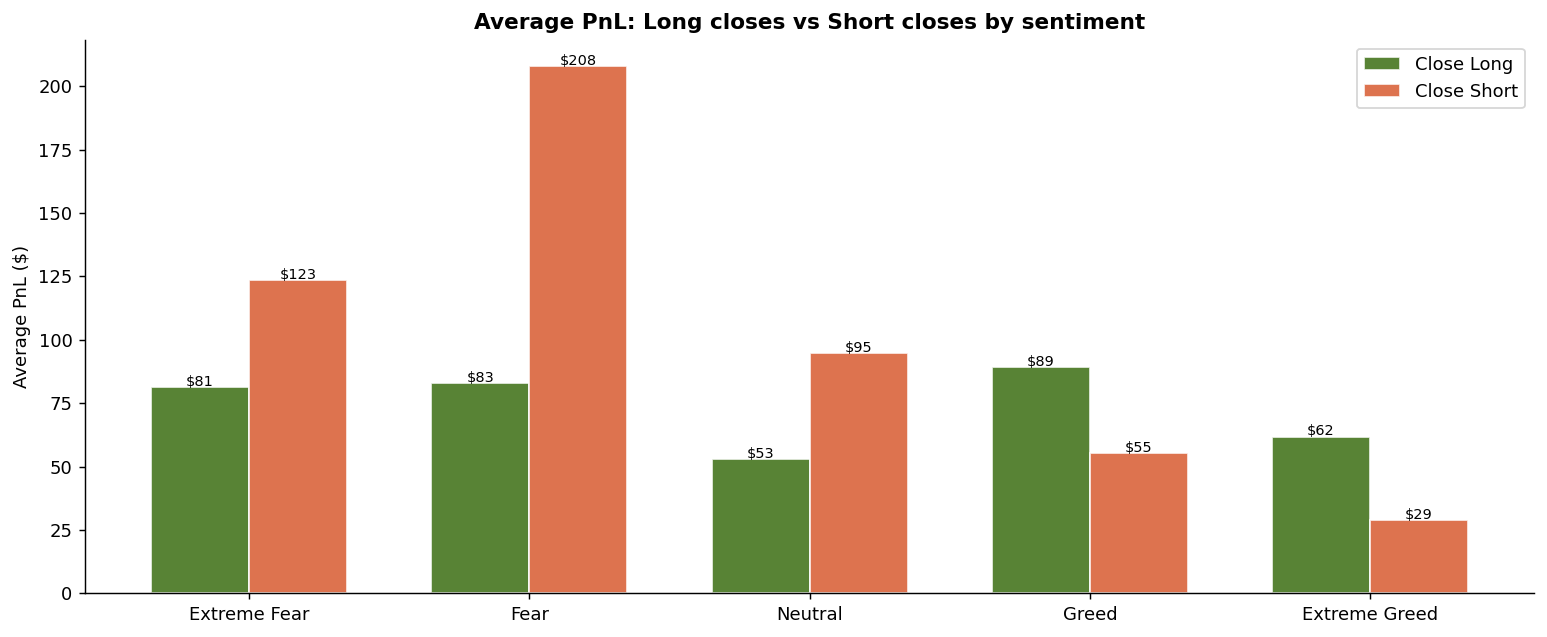

Short closes (closing a short position) are far more profitable during Fear ($207) than Extreme Greed ($29).
This confirms: the best short exits happen when the market is most fearful.


In [16]:
# --- Long vs Short performance by sentiment ---
longs  = closing[closing['Direction'] == 'Close Long']
shorts = closing[closing['Direction'] == 'Close Short']

long_avg  = longs.groupby('classification')['Closed PnL'].mean().reindex(SENT_ORDER)
short_avg = shorts.groupby('classification')['Closed PnL'].mean().reindex(SENT_ORDER)

x = np.arange(len(SENT_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, long_avg, width, label='Close Long', color='#3B6D11', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, short_avg, width, label='Close Short', color='#D85A30', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(SENT_ORDER)
ax.set_ylabel('Average PnL ($)')
ax.set_title('Average PnL: Long closes vs Short closes by sentiment', fontweight='bold')
ax.legend()
for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'${bar.get_height():.0f}', ha='center', fontsize=8)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'${bar.get_height():.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()
print('Short closes (closing a short position) are far more profitable during Fear ($207) than Extreme Greed ($29).')
print('This confirms: the best short exits happen when the market is most fearful.')

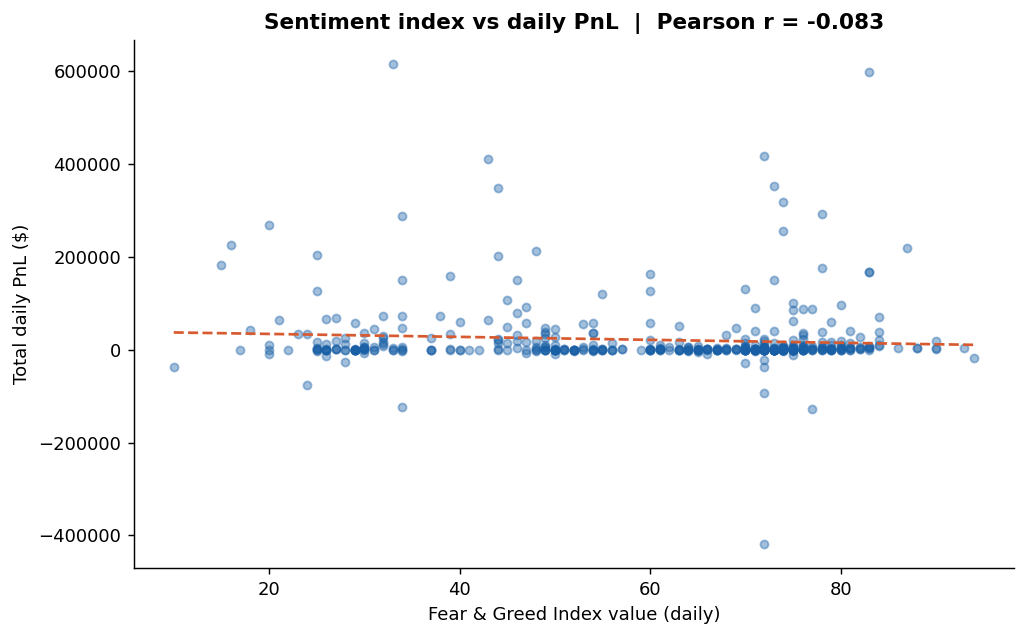

Correlation: -0.0826 — Near zero. Sentiment alone does not predict daily PnL.
The relationship is non-linear; position direction matters more than the raw index level.


In [17]:
# --- Sentiment correlation check ---
daily = merged.groupby('date_only').agg(total_pnl=('Closed PnL','sum'), sentiment_value=('value','first')).dropna()
corr = daily['sentiment_value'].corr(daily['total_pnl'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(daily['sentiment_value'], daily['total_pnl'], alpha=0.4, s=20, color='#185FA5')
z = np.polyfit(daily['sentiment_value'], daily['total_pnl'], 1)
p = np.poly1d(z)
ax.plot(sorted(daily['sentiment_value']), p(sorted(daily['sentiment_value'])), color='#D85A30', linewidth=1.5, linestyle='--')
ax.set_xlabel('Fear & Greed Index value (daily)')
ax.set_ylabel('Total daily PnL ($)')
ax.set_title(f'Sentiment index vs daily PnL  |  Pearson r = {corr:.3f}', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Correlation: {corr:.4f} — Near zero. Sentiment alone does not predict daily PnL.')
print('The relationship is non-linear; position direction matters more than the raw index level.')

## 7. Buy vs Sell Behavior Across Sentiments

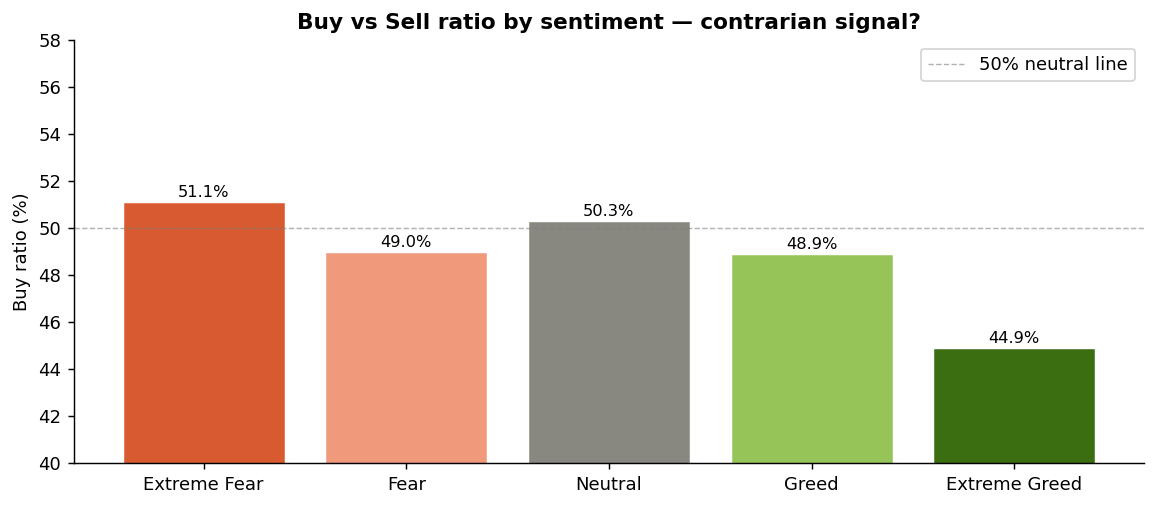

During Extreme Greed, buy ratio drops to 44.9% — traders sell more at market peaks (contrarian).
During Extreme Fear and Neutral, buy ratio is slightly above 50% — slight dip-buying tendency.


In [18]:
# --- BUY ratio per sentiment (contrarian signal check) ---
side_sent = merged.groupby(['classification','Side']).size().unstack(fill_value=0).reindex(SENT_ORDER)
side_sent['buy_ratio'] = (side_sent['BUY'] / (side_sent['BUY'] + side_sent['SELL']) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(SENT_ORDER, side_sent['buy_ratio'], color=SENT_COLORS, edgecolor='white', linewidth=0.8)
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='50% neutral line')
ax.set_ylim(40, 58)
ax.set_ylabel('Buy ratio (%)')
ax.set_title('Buy vs Sell ratio by sentiment — contrarian signal?', fontweight='bold')
ax.legend()
for bar, val in zip(bars, side_sent['buy_ratio']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print('During Extreme Greed, buy ratio drops to 44.9% — traders sell more at market peaks (contrarian).')
print('During Extreme Fear and Neutral, buy ratio is slightly above 50% — slight dip-buying tendency.')

## 8. Monthly PnL Trend

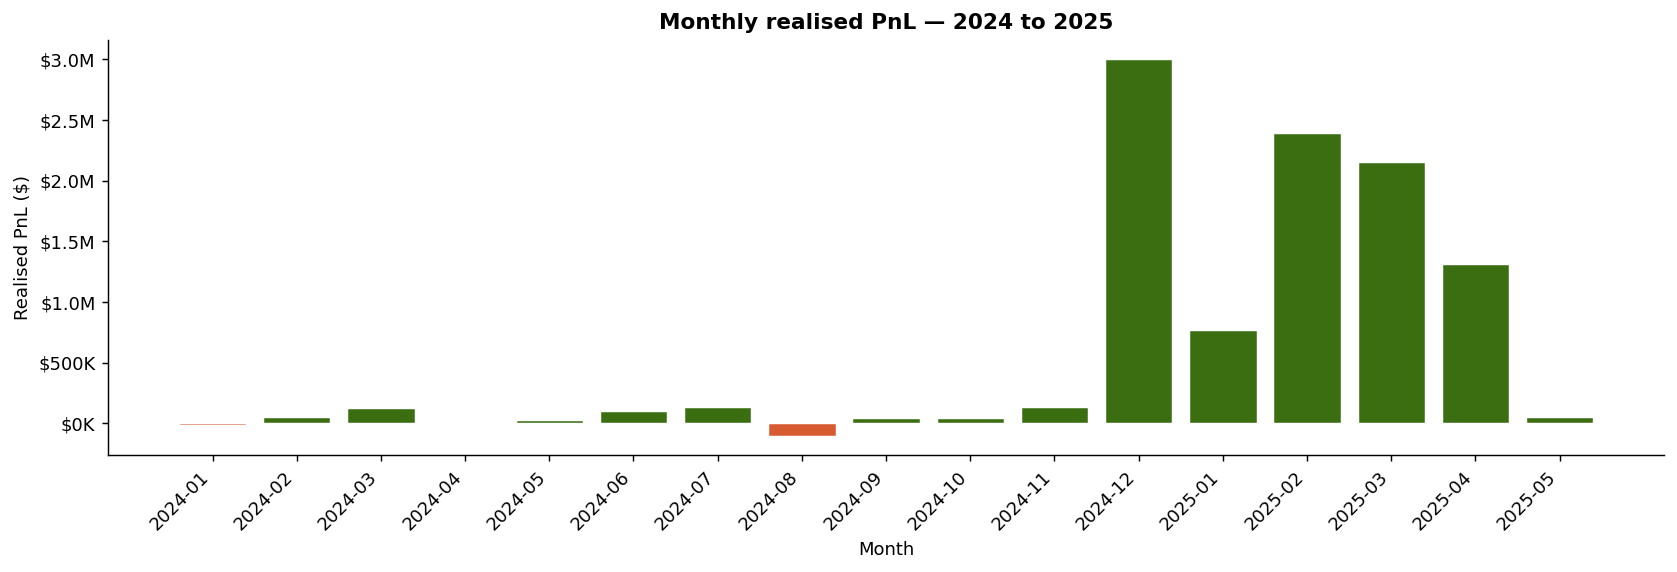

December 2024 ($3.0M) and Feb–Mar 2025 (~$2.4M each) drove the majority of total PnL.
August 2024 (-$107K) was the only significantly loss-making month.


In [19]:
monthly_pnl = merged.groupby('month')['Closed PnL'].sum().reset_index()
monthly_pnl['month_str'] = monthly_pnl['month'].astype(str)
monthly_pnl = monthly_pnl[monthly_pnl['month_str'] >= '2024-01'].copy()
monthly_pnl['color'] = monthly_pnl['Closed PnL'].apply(lambda x: '#3B6D11' if x >= 0 else '#D85A30')

fig, ax = plt.subplots(figsize=(13, 4.5))
bars = ax.bar(monthly_pnl['month_str'], monthly_pnl['Closed PnL'],
              color=monthly_pnl['color'], edgecolor='white', linewidth=0.8)
ax.set_xlabel('Month')
ax.set_ylabel('Realised PnL ($)')
ax.set_title('Monthly realised PnL — 2024 to 2025', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if abs(x)>=1e6 else f'${x/1e3:.0f}K'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('December 2024 ($3.0M) and Feb–Mar 2025 (~$2.4M each) drove the majority of total PnL.')
print('August 2024 (-$107K) was the only significantly loss-making month.')

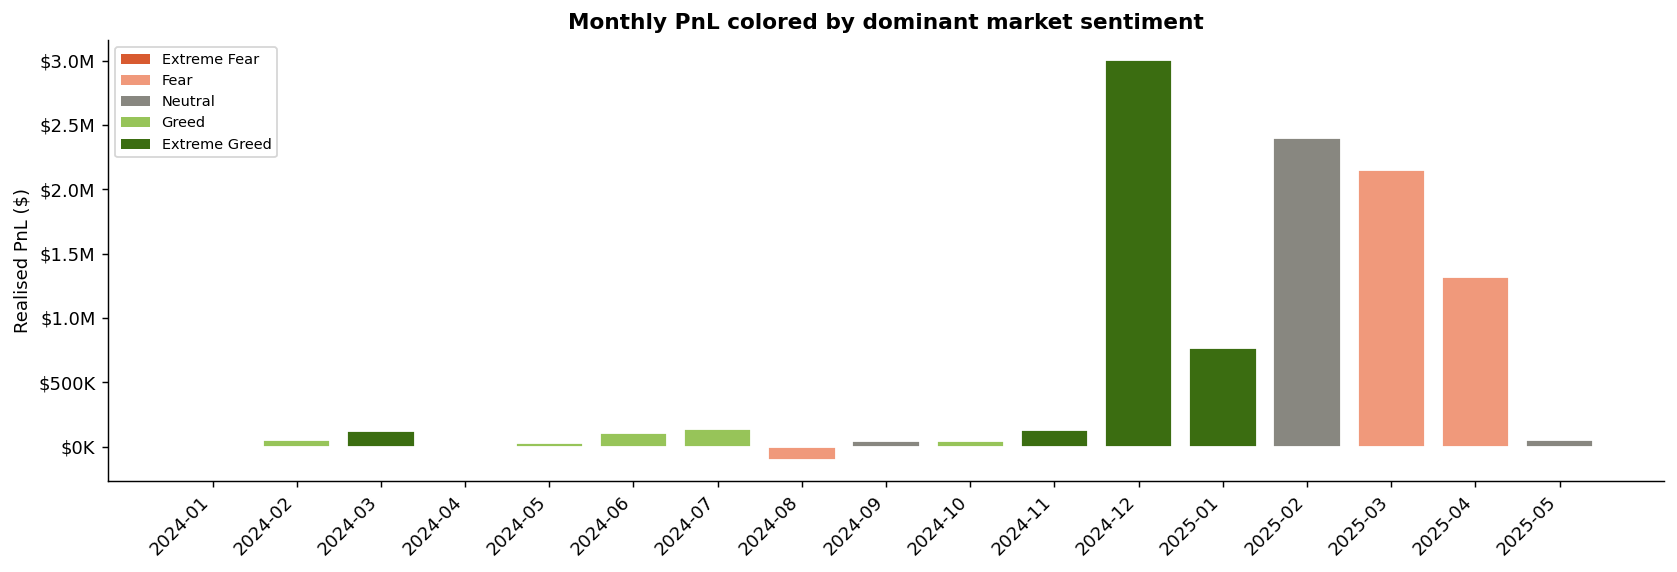

In [20]:
# --- Monthly PnL colored by dominant sentiment ---
monthly_sent = merged.groupby('month').agg(
    total_pnl = ('Closed PnL', 'sum'),
    dominant_sent = ('classification', lambda x: x.mode()[0])
).reset_index()
monthly_sent['month_str'] = monthly_sent['month'].astype(str)
monthly_sent = monthly_sent[monthly_sent['month_str'] >= '2024-01']

color_map = dict(zip(SENT_ORDER, SENT_COLORS))
bar_colors = monthly_sent['dominant_sent'].map(color_map)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(monthly_sent['month_str'], monthly_sent['total_pnl'], color=bar_colors, edgecolor='white')
ax.set_title('Monthly PnL colored by dominant market sentiment', fontweight='bold')
ax.set_ylabel('Realised PnL ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if abs(x)>=1e6 else f'${x/1e3:.0f}K'))
plt.xticks(rotation=45, ha='right')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[s], label=s) for s in SENT_ORDER]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Per-Trader Analysis

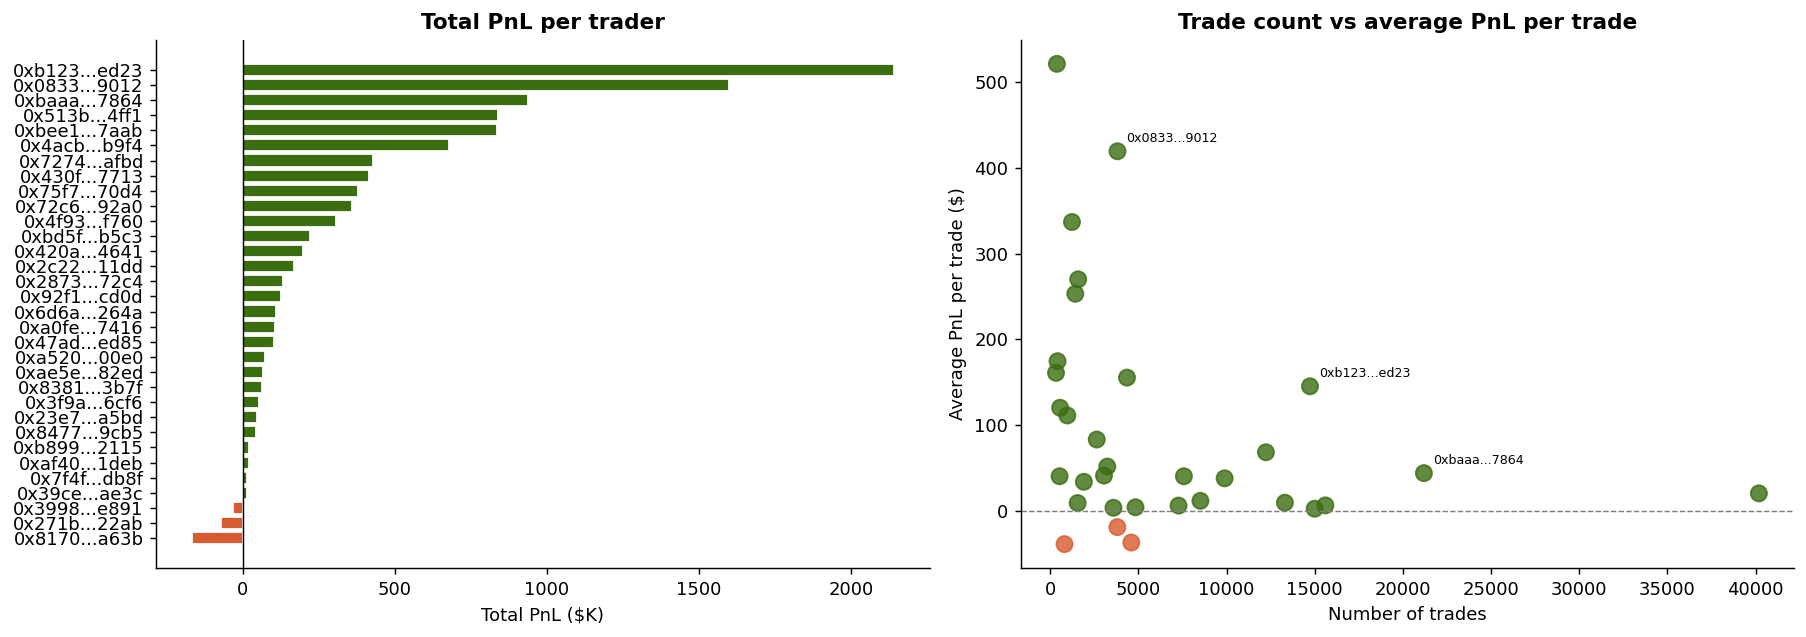


Top 5 traders:
   short_addr    total_pnl    avg_pnl  trade_count  pnl_share
0xb123...ed23 2.143383e+06 145.481748        14733       20.9
0x0833...9012 1.600230e+06 419.127768         3818       15.6
0xbaaa...7864 9.401638e+05  44.364091        21192        9.2
0x513b...4ff1 8.404226e+05  68.684419        12236        8.2
0xbee1...7aab 8.360806e+05  20.806305        40184        8.2

Bottom 3 traders (loss-making):
   short_addr      total_pnl    avg_pnl  trade_count
0x3998...e891  -31203.599986 -38.286626          815
0x271b...22ab  -70436.191318 -18.492043         3809
0x8170...a63b -167621.124781 -36.431455         4601


In [21]:
# --- Trader leaderboard ---
acct = merged.groupby('Account').agg(
    total_pnl  = ('Closed PnL', 'sum'),
    avg_pnl    = ('Closed PnL', 'mean'),
    trade_count= ('Closed PnL', 'count'),
    total_vol  = ('Size USD', 'sum')
).sort_values('total_pnl', ascending=False).reset_index()
acct['short_addr'] = acct['Account'].str[:6] + '...' + acct['Account'].str[-4:]
acct['pnl_share'] = (acct['total_pnl'] / acct['total_pnl'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_bar = ['#3B6D11' if v >= 0 else '#D85A30' for v in acct['total_pnl']]
axes[0].barh(acct['short_addr'][::-1], acct['total_pnl'][::-1]/1000, color=colors_bar[::-1], edgecolor='white')
axes[0].set_xlabel('Total PnL ($K)')
axes[0].set_title('Total PnL per trader', fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)

# Scatter: trade count vs avg pnl
scatter_colors = ['#3B6D11' if v >= 0 else '#D85A30' for v in acct['avg_pnl']]
axes[1].scatter(acct['trade_count'], acct['avg_pnl'], c=scatter_colors, s=80, alpha=0.8)
axes[1].set_xlabel('Number of trades')
axes[1].set_ylabel('Average PnL per trade ($)')
axes[1].set_title('Trade count vs average PnL per trade', fontweight='bold')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
for _, row in acct.head(3).iterrows():
    axes[1].annotate(row['short_addr'], (row['trade_count'], row['avg_pnl']),
                     fontsize=7, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print('\nTop 5 traders:')
print(acct[['short_addr','total_pnl','avg_pnl','trade_count','pnl_share']].head(5).to_string(index=False))
print('\nBottom 3 traders (loss-making):')
print(acct[acct['total_pnl']<0][['short_addr','total_pnl','avg_pnl','trade_count']].to_string(index=False))

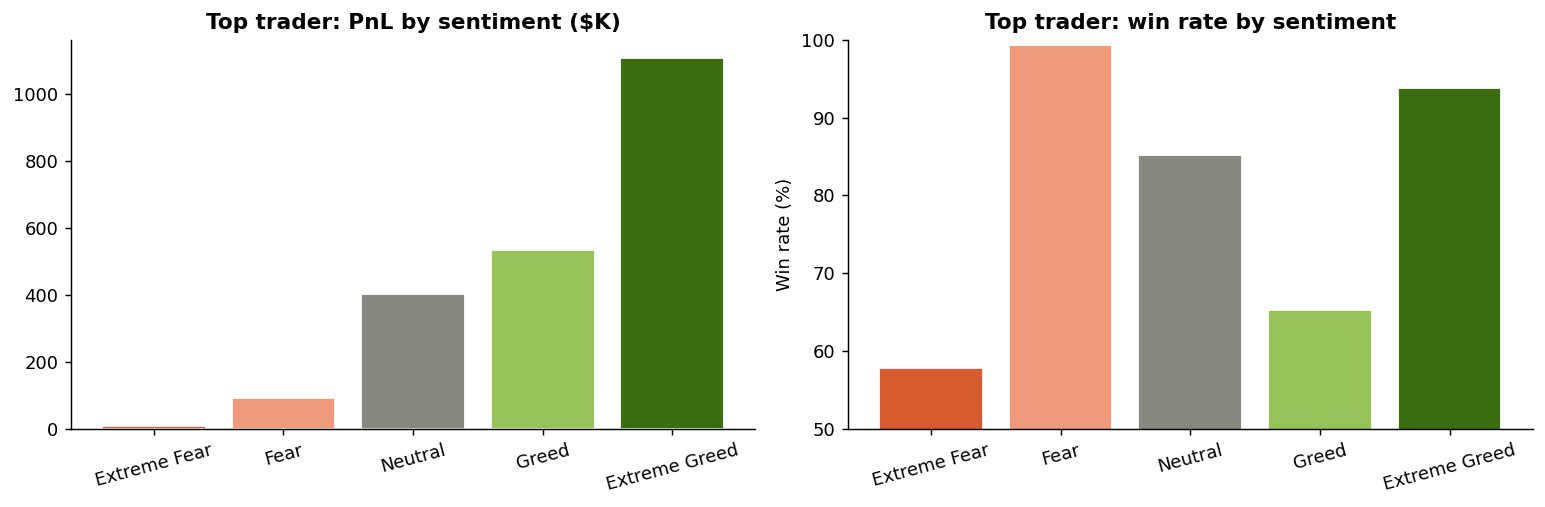

In [22]:
# --- Best trader's preferred sentiment ---
top_trader = acct.iloc[0]['Account']
top_df = merged[merged['Account'] == top_trader]

top_sent_pnl = top_df.groupby('classification')['Closed PnL'].sum().reindex(SENT_ORDER)
top_sent_wr  = top_df[top_df['Closed PnL']!=0].groupby('classification').apply(lambda x: (x['Closed PnL']>0).mean()).reindex(SENT_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(SENT_ORDER, top_sent_pnl/1000, color=SENT_COLORS, edgecolor='white')
axes[0].set_title(f'Top trader: PnL by sentiment ($K)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(SENT_ORDER, top_sent_wr*100, color=SENT_COLORS, edgecolor='white')
axes[1].set_ylim(50,100)
axes[1].set_title('Top trader: win rate by sentiment', fontweight='bold')
axes[1].set_ylabel('Win rate (%)')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 10. Key Findings & Strategy Insights

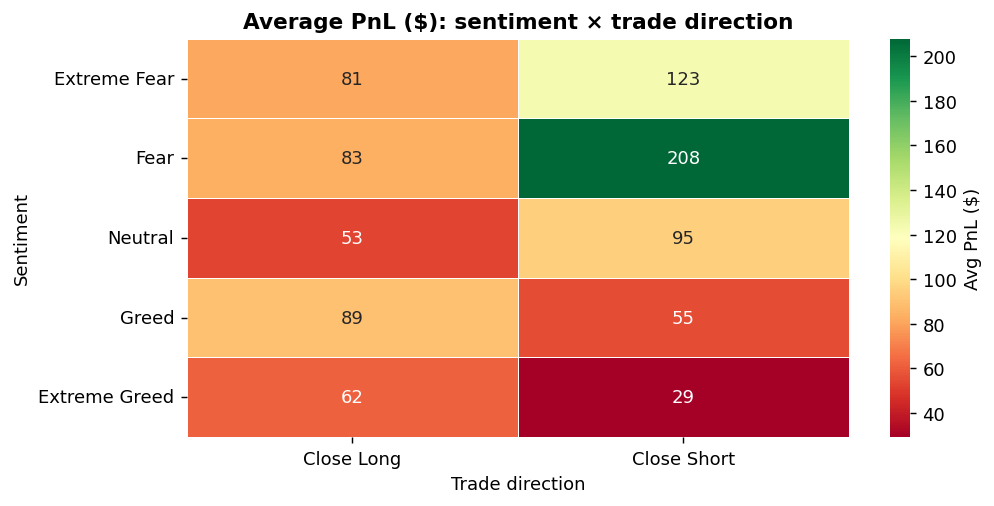

Hot spots: Close Short during Fear ($207) and Close Long during Greed ($89) are the best combos.


In [23]:
# --- Summary heatmap: avg PnL by sentiment x direction ---
key_dirs = ['Close Long', 'Close Short']
heat_df = closing[closing['Direction'].isin(key_dirs)].groupby(
    ['classification', 'Direction'])['Closed PnL'].mean().unstack().reindex(SENT_ORDER)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heat_df, annot=True, fmt='.0f', cmap='RdYlGn', linewidths=0.5,
            cbar_kws={'label': 'Avg PnL ($)'}, ax=ax)
ax.set_title('Average PnL ($): sentiment × trade direction', fontweight='bold')
ax.set_xlabel('Trade direction')
ax.set_ylabel('Sentiment')
plt.tight_layout()
plt.show()
print('Hot spots: Close Short during Fear ($207) and Close Long during Greed ($89) are the best combos.')

In [24]:
# --- Best single trades ---
print('=== 5 Biggest Winning Trades ===')
best = merged.nlargest(5, 'Closed PnL')[['Account','Coin','Closed PnL','classification','Direction','Timestamp IST']].copy()
best['Account'] = best['Account'].str[:10] + '...'
print(best.to_string(index=False))

print('\n=== 5 Biggest Losing Trades ===')
worst = merged.nsmallest(5, 'Closed PnL')[['Account','Coin','Closed PnL','classification','Direction','Timestamp IST']].copy()
worst['Account'] = worst['Account'].str[:10] + '...'
print(worst.to_string(index=False))

=== 5 Biggest Winning Trades ===
      Account Coin   Closed PnL classification   Direction    Timestamp IST
0x083384f8...  ETH 135329.09010           Fear Close Short 12-04-2025 12:31
0x083384f8...  ETH 115287.00000   Extreme Fear Close Short 28-02-2025 01:02
0x083384f8...  ETH  78682.72032           Fear Close Short 12-04-2025 12:31
0x72743ae2...  ETH  74530.52371          Greed Close Short 08-01-2025 19:42
0x083384f8...  ETH  72377.74821           Fear Close Short 12-04-2025 12:22

=== 5 Biggest Losing Trades ===
      Account  Coin    Closed PnL classification   Direction    Timestamp IST
0x083384f8...   ETH -117990.10410          Greed Close Short 06-12-2024 23:15
0x8170715b... TRUMP  -83056.32000          Greed Close Short 23-04-2025 21:50
0x8170715b... TRUMP  -41910.06915          Greed Close Short 23-04-2025 21:49
0x72743ae2...   SOL  -35681.74723           Fear Close Short 18-04-2025 20:03
0x8170715b... TRUMP  -34338.53409          Greed Close Short 23-04-2025 21:49


In [25]:
# --- Final strategy summary print ---
print('=' * 65)
print('  STRATEGY INSIGHTS SUMMARY')
print('=' * 65)

insights = [
    ('1', 'Short exits in Fear regimes',
     'Closing short positions during Fear delivers avg $207/trade —\n     7x more than the same move in Extreme Greed ($29).'),
    ('2', 'Extreme Greed = high win rate, lower per-trade value',
     'Best win rate at 89.2% but avg ticket is $130. Many small\n     wins vs fewer big wins in Fear periods.'),
    ('3', 'Fear drives the most volume & largest tickets',
     '$483M volume in Fear — traders size up when markets panic.\n     Average trade size: $7,816 vs $3,112 in Extreme Greed.'),
    ('4', 'Sentiment index has near-zero correlation with daily PnL',
     'r = -0.08. Regime matters, but direction within regime\n     matters far more for predicting outcomes.'),
    ('5', 'Top 2 wallets captured 36% of all profits',
     'Extreme alpha concentration. The pool is not uniformly\n     skilled — top traders drive disproportionate PnL.'),
    ('6', 'December 2024 was a one-in-a-year outlier',
     '$3.0M in one month (29% of annual total). Bitcoin bull run\n     post-US election caused a sentiment + price shock.'),
]

for num, title, detail in insights:
    print(f'\n  [{num}] {title}')
    print(f'     {detail}')

print('\n' + '=' * 65)

  STRATEGY INSIGHTS SUMMARY

  [1] Short exits in Fear regimes
     Closing short positions during Fear delivers avg $207/trade —
     7x more than the same move in Extreme Greed ($29).

  [2] Extreme Greed = high win rate, lower per-trade value
     Best win rate at 89.2% but avg ticket is $130. Many small
     wins vs fewer big wins in Fear periods.

  [3] Fear drives the most volume & largest tickets
     $483M volume in Fear — traders size up when markets panic.
     Average trade size: $7,816 vs $3,112 in Extreme Greed.

  [4] Sentiment index has near-zero correlation with daily PnL
     r = -0.08. Regime matters, but direction within regime
     matters far more for predicting outcomes.

  [5] Top 2 wallets captured 36% of all profits
     Extreme alpha concentration. The pool is not uniformly
     skilled — top traders drive disproportionate PnL.

  [6] December 2024 was a one-in-a-year outlier
     $3.0M in one month (29% of annual total). Bitcoin bull run
     post-US election

## 11. Interactive Dashboard (Plotly)

In [26]:
# Interactive: Win rate + Avg PnL side by side
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Win rate by sentiment (%)', 'Average PnL per trade ($)'])

fig.add_trace(go.Bar(x=SENT_ORDER, y=wr['win_rate_pct'],
                     marker_color=SENT_COLORS, name='Win rate',
                     text=wr['win_rate_pct'].round(1).astype(str)+'%',
                     textposition='outside'), row=1, col=1)
fig.add_trace(go.Bar(x=SENT_ORDER, y=wr['avg_pnl'].round(0),
                     marker_color=SENT_COLORS, name='Avg PnL',
                     text='$'+wr['avg_pnl'].round(0).astype(int).astype(str),
                     textposition='outside'), row=1, col=2)

fig.update_layout(height=450, showlegend=False,
                  title_text='Trader performance by market sentiment',
                  plot_bgcolor='white')
fig.update_yaxes(range=[60, 95], row=1, col=1)
fig.show()

In [27]:
# Interactive: Monthly PnL
fig = go.Figure()
fig.add_trace(go.Bar(
    x=monthly_pnl['month_str'],
    y=monthly_pnl['Closed PnL'],
    marker_color=monthly_pnl['color'],
    hovertemplate='%{x}<br>PnL: $%{y:,.0f}<extra></extra>'
))
fig.update_layout(
    title='Monthly Realised PnL (2024–2025)',
    xaxis_title='Month', yaxis_title='PnL ($)',
    height=420, plot_bgcolor='white'
)
fig.show()

In [28]:
# Interactive: Long vs Short avg PnL grouped
fig = go.Figure()
fig.add_trace(go.Bar(name='Close Long', x=SENT_ORDER, y=long_avg.round(0),
                     marker_color='#3B6D11', opacity=0.85))
fig.add_trace(go.Bar(name='Close Short', x=SENT_ORDER, y=short_avg.round(0),
                     marker_color='#D85A30', opacity=0.85))
fig.update_layout(barmode='group',
                  title='Avg PnL: Long closes vs Short closes by sentiment',
                  yaxis_title='Avg PnL ($)', height=430,
                  plot_bgcolor='white')
fig.show()

In [29]:
# Interactive: Scatter plot — daily sentiment value vs PnL
daily_reset = daily.reset_index()
daily_reset['date_str'] = daily_reset['date_only'].astype(str)

fig = px.scatter(daily_reset, x='sentiment_value', y='total_pnl',
                 hover_data=['date_str'],
                 trendline='ols',
                 labels={'sentiment_value': 'Fear & Greed Index', 'total_pnl': 'Daily PnL ($)'},
                 title=f'Daily sentiment vs daily PnL  |  Correlation = {corr:.3f}',
                 color_discrete_sequence=['#185FA5'])
fig.update_layout(height=430, plot_bgcolor='white')
fig.show()